In [9]:
import os

import numpy as np
import pandas as pd

from idsia_mpc.control_engineering_practice.plot_utils import setup_matplotlib

In [10]:
setup_matplotlib()

In [11]:
df = pd.read_csv('idsia_mpc/control_engineering_practice/sysid/out/new/predictions/lstm_model_multistep/melon.csv')

In [14]:
df

,t,x_true,x_pred,y_true,y_pred,z_true,z_pred,roll_true,roll_pred,pitch_true,...,vy_true,vy_pred,vz_true,vz_pred,wx_true,wx_pred,wy_true,wy_pred,wz_true,wz_pred
0,0.00,0.031345,-0.000742,0.031121,0.063454,0.548833,0.537605,-0.007224,0.001010,0.006963,...,0.003679,0.005391,1.013759,1.014223,-0.018813,-0.273141,0.249558,0.263867,0.016859,-0.031723
1,0.01,0.031345,0.002525,0.031121,0.070796,0.548833,0.529671,-0.010030,-0.001076,0.006973,...,0.003679,0.002692,1.013752,1.014227,0.178187,-0.289463,1.053558,0.480063,-0.038141,-0.028040
2,0.02,0.031345,-0.000905,0.030121,0.069517,0.551833,0.522266,-0.007204,-0.008374,0.012574,...,0.003679,0.001461,1.013751,1.014598,0.244187,-0.212377,1.495558,0.658213,0.031859,-0.024007
3,0.03,0.031345,0.005009,0.030121,0.075369,0.552833,0.518914,-0.007191,-0.011865,0.026594,...,0.002295,0.000634,1.013699,1.015280,0.166187,-0.176873,1.272558,0.555907,0.017859,-0.016085
4,0.04,0.031345,0.011372,0.030121,0.084080,0.549833,0.522423,-0.004299,-0.012778,0.040625,...,0.003679,0.000098,1.013602,1.016095,-0.042813,-0.170360,0.592558,0.237193,-0.061141,-0.008943
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6494,64.94,0.017345,-0.501572,0.003121,-0.361921,1.290833,1.137133,-0.007187,-0.030730,0.012584,...,0.005062,0.000303,1.013748,1.013680,0.115187,0.128065,-0.027442,-0.270854,-0.013141,-0.030373
6495,64.95,0.017345,-0.500614,0.003121,-0.356902,1.290833,1.136851,-0.004381,-0.030185,0.012570,...,0.005062,0.000134,1.013753,1.013661,0.081187,0.108060,-0.081442,-0.302440,-0.008141,-0.032872
6496,64.96,0.017345,-0.500245,0.003121,-0.351911,1.290833,1.133973,-0.004395,-0.030210,0.009764,...,0.005062,0.000164,1.013758,1.013720,0.065187,0.106553,-0.055442,-0.324308,-0.014141,-0.033673
6497,64.97,0.017345,-0.500569,0.003121,-0.352596,1.286833,1.130465,-0.004395,-0.029799,0.009764,...,0.005062,-0.000049,1.013758,1.013964,0.096187,0.137272,-0.026442,-0.324895,-0.008141,-0.039586


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


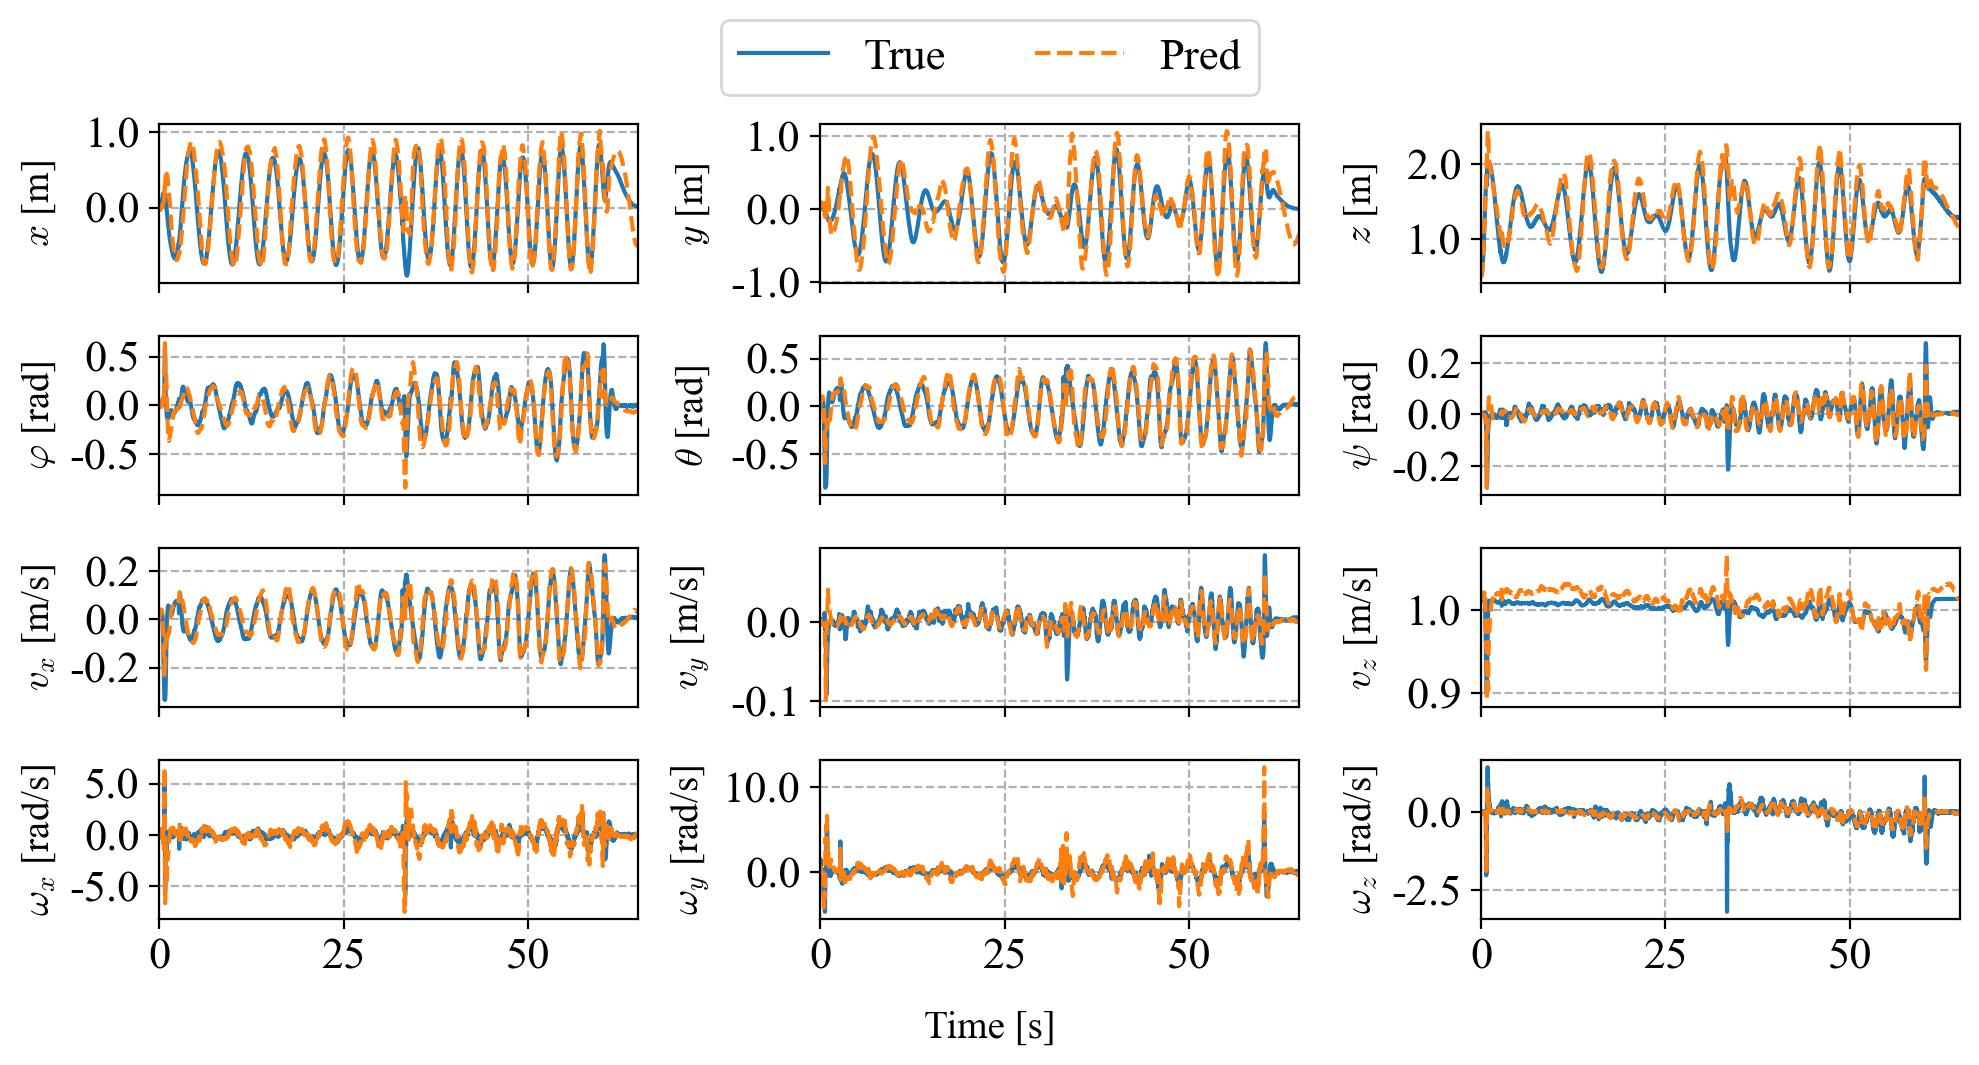

In [43]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter

# --- Create 4x3 layout ---
fig, axs = plt.subplots(4, 3, figsize=(10, 5), sharex=True, dpi=200, constrained_layout=False)

# --- Define state variables (each row = 3 columns) ---
state_cols = [
    ['x', 'y', 'z'],
    ['roll', 'pitch', 'yaw'],
    ['vx', 'vy', 'vz'],
    ['wx', 'wy', 'wz']
]
state_labels = [
    ['$x$ [m]', '$y$ [m]', '$z$ [m]'],
    [r'$\varphi$ [rad]', r'$\theta$ [rad]', r'$\psi$ [rad]'],
    [r'$v_x$ [m/s]', r'$v_y$ [m/s]', r'$v_z$ [m/s]'],
    [r'$\omega_x$ [rad/s]', r'$\omega_y$ [rad/s]', r'$\omega_z$ [rad/s]']
]

t = df['t']

# --- Plot states ---
for r in range(4):
    for c in range(3):
        state_name = state_cols[r][c]
        ax = axs[r, c]

        true_col = f"{state_name}_true"
        pred_col = f"{state_name}_pred"

        if true_col in df and pred_col in df:
            ax.plot(t, df[true_col], color='tab:blue', label='True')
            ax.plot(t, df[pred_col], color='tab:orange', linestyle='--', label='Pred')

        ax.set_ylabel(state_labels[r][c], fontsize=14)
        ax.grid(True)
        ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

# --- Align all y-labels vertically ---
fig.align_ylabels(axs[:, 0])
fig.align_ylabels(axs[:, 1])
fig.align_ylabels(axs[:, 2])

# --- Common labels & layout ---
fig.text(0.5, 0.01, "Time [s]", ha='center', va='center', fontsize=14)

# Create legend only once
handles, labels = axs[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncols=4, bbox_to_anchor=(0.5, 1.04))

# Adjust layout to avoid clipping
plt.subplots_adjust(top=0.88, bottom=0.12, hspace=0.2, wspace=0.45)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # ensure text and legend fit nicely

plt.savefig('idsia_mpc/control_engineering_practice/sysid/out/figures/lstm_melon.pdf', bbox_inches='tight')
plt.show()


In [44]:
np.rad2deg(.5)

np.float64(28.64788975654116)